# Spatial indexing

This notebook is about spatial indexing, which is the process of organizing points to make queries and data processing more efficient. It uses spatial data structures to quickly find subsets of points based on their location. This speeds up distance and neighborhood computations, which are key steps in many pointcloud algorithms.

After introducing the concepts of distance, neighborhoods, and the limits of brute-force search, this notebook presents three common spatial data structures: voxel grids, octrees, and kd-trees.

In [24]:
# Necessary imports
import sys
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

sys.path.append("./utils")
from plot_utils import cuboid_to_poly3D

# Load our bunny pointcloud
points = np.loadtxt("./data/stanford_bunny_simple.xyz")


## About distances, neighborhoods and the "brute force" approach

### Distances

A distance $d$ measures how far apart two points $p$ and $q$ are.

The most common distance for pointclouds is the **Euclidean distance**, defined as:

\begin{equation*}
    d(p, q) = \sqrt{(p_x - q_x)^2 + (p_y - q_y)^2 + (p_z - q_z)^2}
\end{equation*}

It corresponds to the length of the straight line between the two points.

Although Euclidean distance is used most of the time, other distance definitions are sometimes useful. For example, the **Manhattan distance** (or **1-distance**) is defined as:

\begin{equation*}
    d_{1}(p, q) = |p_x - q_x| + |p_y - q_y| + |p_z - q_z|
\end{equation*}

and the **Chebyshev distance** (or **$\infty$-distance**) as:

\begin{equation*}
    d_{\infty}(p, q) = \max(|p_x - q_x|, |p_y - q_y|, |p_z - q_z|)
\end{equation*}

Unless stated otherwise, distances in this notebook refer to the Euclidean distance.

In practice, the Euclidean distance between two points is obtained by subtracting their coordinates and computing the norm of the resulting vector. NumPy provides this operation through `np.linalg.norm`.

Euclidean distance between [ 90. 150. -10.] and [ 54.3485 127.7255  45.5547] is: 69.66711917820342


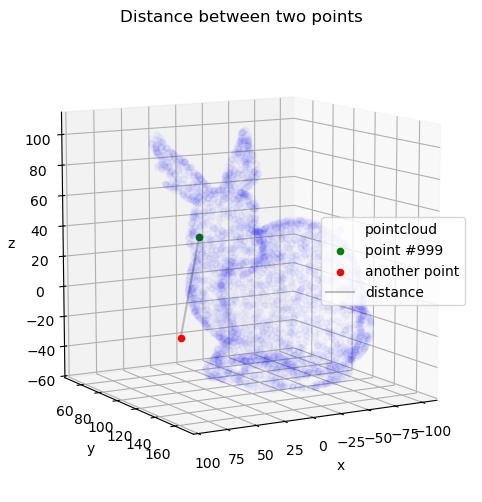

In [ ]:
# Create another point
another_point = np.array([90., 150., -10.])
# Compute the Euclidean distance to point #999
point_999 = points[999]
dist = np.linalg.norm(point_999 - another_point)
print(f"Euclidean distance between {another_point} and {point_999} is: {dist}")

# Plot pointcloud and the two points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          color="blue", alpha=0.02, label="pointcloud")
ax.scatter(point_999[0], point_999[1], point_999[2],
          color="green", label="point #999")
ax.scatter(another_point[0], another_point[1], another_point[2],
          color="red", label="another point")
ax.plot([another_point[0], point_999[0]], [another_point[1], point_999[1]],
[another_point[2], point_999[2]], color='gray', alpha=0.5, label="distance")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_box_aspect([1, 1, 1])
ax.set_title("Distance between two points")
plt.show()


### Neighborhoods

A neighborhood is the set of points located close to a **query point** $q$.

In pointcloud processing, two types of neighborhoods are commonly used:

1. **Radius neighborhood** (or spherical neighborhood): all points located within a distance $r$ of the query point are selected. This search is often called a **ball query**.
\begin{equation*}
    N_{r}(q) = \{ p \in P : d(p, q) < r \}
\end{equation*}
The number of neighbors is not known in advance and depends on the local point density.

2. **k-nearest-neighbor neighborhood** (or k-nn): the $k$ points closest to the query point are selected.
In this case, the neighborhood always contains exactly $k$ points, while the distance to the farthest neighbor may vary from one query point to another.

The following query point and search parameters will be used throughout the notebook: $k$ number of neighbors and $r$ search radius.

In [26]:
# Query point used through the notebook
query_point = another_point
# Parameters for neighborhood queries
k = 5
r = 50

### The "brute-force" approach

The simplest way to compute a neighborhood is the *brute-force approach*.

Given a query point, it consists of:

1. Computing the distance to every point in the pointcloud.

2. Selecting the points that belong to the neighborhood:
   * the $k$ closest points for a k-nn search;
   * all points within a radius $r$ for a radius search.

This approach is easy to understand and implement, but it becomes inefficient for large pointclouds because **every query requires checking all points**, including points that are very far from the query point. For a pointcloud containing $n$ points, computing a neighborhood for every point requires on the order of $n^2$ distance computations.

The main idea behind spatial structures is to **partition the 3D space into regions containing subsets of the pointcloud**. During a neighborhood search, these regions help identify where relevant points may be located, making it unnecessary to compare the query point with every point in the pointcloud.

In [27]:
def brute_force_search(points, query_point, k):
    """Find the k nearest neighbors using brute force search."""

    # Compute the distance from the query point to every point
    dists = np.linalg.norm(points - query_point, axis=1)
    # Sort the points by distance
    sorted_inds = np.argsort(dists)
    # Return the indices of the k closest points
    return sorted_inds[:k]

def brute_force_ball_search(points, query_point, r):
    """Find all points within a radius r using brute force search."""

    # Compute the distance from the query point to every point
    dists = np.linalg.norm(points - query_point, axis=1)
    # Return the indices of points within radius r
    return np.flatnonzero(dists < r)


The 5-nearest neighbors are points # [ 183  893 3550   53  221]


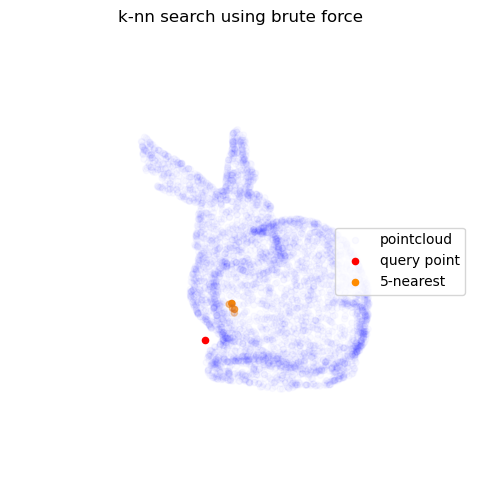

In [ ]:
# Try brute force search
knn_brute_force = brute_force_search(points, query_point, k)
with np.printoptions(precision=2, suppress=True):
    print(f"The {k}-nearest neighbors are points #", knn_brute_force)

# Plot results
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          color="blue", alpha=0.02, label="pointcloud")
ax.scatter(query_point[0], query_point[1], query_point[2],
          color="red", label="query point")
ax.scatter(points[knn_brute_force, 0], points[knn_brute_force, 1],
        points[knn_brute_force, 2], color="darkorange", label=f"{k}-nearest")
ax.legend(loc="right")
ax.view_init(10, 50)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.set_title("k-nn search using brute force")
plt.show()


Neighbors within radius 50 are points # [  53  183  221  268  287  436  449  893 1135 1342 1402 1900 1952 2002
 2014 2216 2369 2399 3106 3550 3663 4021 4057]


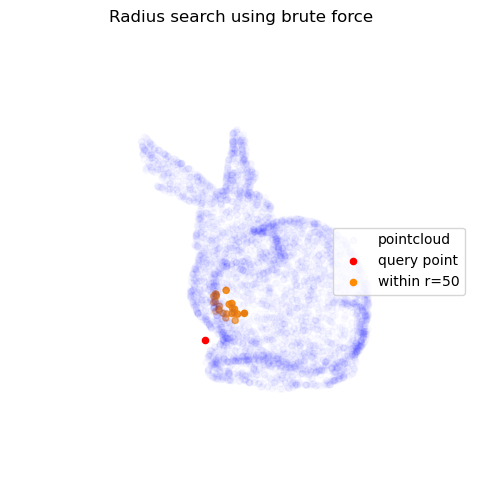

In [ ]:
# Try brute force ball search
ball_brute_force = brute_force_ball_search(points, query_point, r)
print(f"Neighbors within radius {r} are points #", ball_brute_force)

# Plot results
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          color="blue", alpha=0.02, label="pointcloud")
ax.scatter(query_point[0], query_point[1], query_point[2],
          color="red", label="query point")
ax.scatter(points[ball_brute_force, 0], points[ball_brute_force, 1],
        points[ball_brute_force, 2], color="darkorange", label=f"within r={r}")
ax.legend(loc="right")
ax.view_init(10, 50)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.set_title("Radius search using brute force")
plt.show()


## Voxel grids

A simple way to partition the space around a pointcloud is to use a **regular grid**. The grid is made of cells of equal size called **voxels**. A voxel is the 3D equivalent of a pixel, its name is derived from *volume* and *pixel*.

**A voxel grid partitions the space into voxels and associates the points with them**. In practice, it can be viewed as placing points into numbered cubic boxes.

A voxel grid is defined by its **voxel size**, that is, the edge length of each voxel. Smaller voxels result in a finer partition of the space, while larger voxels group more points together. The voxel size therefore controls the level of detail at which the pointcloud is organized and has a direct impact on the efficiency of neighborhood searches.

In the implementation below, each voxel is identified by its coordinates in the grid. For example, with a voxel size of $20$, the voxel identified by $(1, 2, 3)$ starts at position $[20., 40., 60.]$ in the pointcloud coordinate system.

Building a voxel grid consists of two steps:

1. Determine the voxel containing each point.
2. Group points belonging to the same voxel.

In practice, voxel grids are often implemented using a **dictionary** (or **hash table**). The keys are voxel coordinates, such as $(1, 2, 3)$, and the values are the points contained in the corresponding voxels. In this notebook, point indices are stored instead of point coordinates and only occupied voxels are stored, making the structure memory-efficient.

The example below illustrates the construction of a voxel grid in 2D. For visualization purposes, only the $(x, z)$ coordinates are used, so voxels appear as squares rather than cubes.

In [30]:
def points_to_voxels(points, voxel_size):
    """Associate each point with a voxel."""

    # Works for both a single point and an array of points
    if points.ndim==1: 
        points = points.reshape((1, -1))
    # Integer voxel coordinates
    voxel_coords = np.floor(points/voxel_size).astype(int)
    # Tuples can be used as dictionary keys
    return [tuple(c.tolist()) for c in voxel_coords]

def create_voxel_grid(points, voxel_size):
    """Create a voxel grid containing point indices."""

    # Associate each point with a voxel
    voxel_coords = points_to_voxels(points, voxel_size)
    # Create a dictionary {voxel: [point indices]}
    voxel_grid = {}
    for i, coord in enumerate(voxel_coords):
        cell = voxel_grid.setdefault(coord, [])
        cell.append(i) # store point index in the cell
    
    return voxel_grid


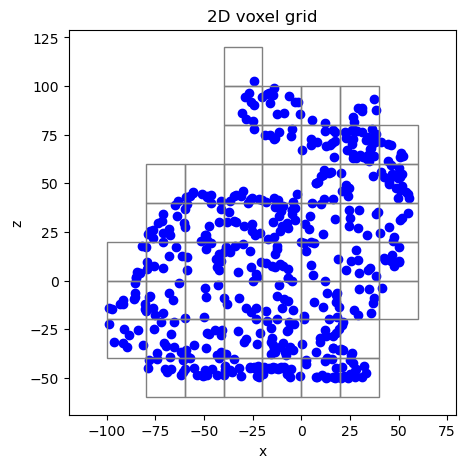

In [31]:
# Voxel size used consistently below
voxel_size = 20.

# Create a 2D pointcloud by keeping one point out of eight and only the x and z
points_sample_2d = points[::8, [0,2]] 
# Build 2D voxel grid
voxel_grid_2d = create_voxel_grid(points_sample_2d, voxel_size)

# Plot the 2D occupied cells of the voxel grid
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(points_sample_2d[:, 0], points_sample_2d[:, 1], color="blue")
# Plot the 2D cells
for key in voxel_grid_2d.keys():
        anchor_point = [voxel_size * d for d in key]
        rect = Rectangle(anchor_point, voxel_size, voxel_size,
                         color="gray", fill=False, lw=1)
        ax.add_patch(rect)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.axis("equal")
ax.set_title("2D voxel grid")
plt.show()


The process is exactly the same in 3D. The only difference is that squares become cubes, so each voxel is identified by three coordinates instead of two. Only occupied voxels are displayed, since empty voxels are not stored in the voxel grid.

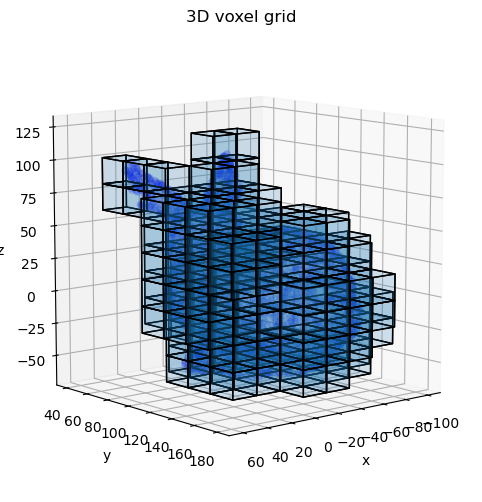

In [32]:
# Build 3D voxel grid
voxel_grid_3d = create_voxel_grid(points, voxel_size)

# Plot the 3D occupied cells of the voxel grid
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color="blue", alpha=0.1)
polys = []
for key in voxel_grid_3d.keys():
    anchor_point = [voxel_size * d for d in key]
    length = width = height = voxel_size
    polys.append(cuboid_to_poly3D(anchor_point, (length, width, height)))
polys = np.concatenate(polys)
pc = Poly3DCollection(polys, edgecolor="k", alpha=0.1)
ax.add_collection3d(pc)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 50)
ax.set_box_aspect([1, 1, 1])
ax.set_title("3D voxel grid")
plt.show()


The main advantage of a voxel grid is that **neighborhood searches only need to inspect voxels close to the query point**.

The voxel containing the query point is identified first, then neighboring voxels are explored. Using voxel coordinates, voxel neighborhoods can be defined with the **Chebyshev distance**. A 1-neighborhood contains the 26 voxels surrounding a query voxel, while neighborhoods of degree 2 and 3 contain 124 and 342 voxels, respectively.

The `VoxelGrid` class below implements this idea by storing point indices in occupied voxels and providing neighborhood search methods. Neighboring voxels are generated directly from voxel coordinates rather than by scanning the entire grid.

In [33]:
class VoxelGrid:
    """Partition 3D space into voxels."""

    class Voxel:
        """Cubic voxel."""

        def __init__(self):
            self.indices = []


    def __init__(self, points, voxel_size):

        self.points = points
        self.voxel_size = voxel_size
        self.voxels = {}
        self._build()

    def _build(self):
        """Associate each point with a voxel."""

        for i, point in enumerate(self.points):
            coords = self.voxel_coordinates(point)
            voxel = self.voxels.setdefault(coords, self.Voxel())
            voxel.indices.append(i)

    def voxel_coordinates(self, point):
        """Coordinates of voxel containing a given point."""
        return tuple(np.floor(point / self.voxel_size).astype(int))

    def voxel_neighbors(self, query_coords, degree):
        """Voxels at a given Chebyshev distance from a query voxel."""

        neighbors = []
        # Generate voxel coordinates at the requested distance
        q_x, q_y, q_z = query_coords
        for d_x in range(-degree, degree + 1):
            for d_y in range(-degree, degree + 1):
                for d_z in range(-degree, degree + 1):
                    # Keep only coordinates exactly at desired distance
                    if max(abs(d_x), abs(d_y), abs(d_z)) != degree:
                        continue
                    coords = (q_x + d_x, q_y + d_y, q_z + d_z)
                    voxel = self.voxels.get(coords)
                    # Only occupied voxels are stored
                    if voxel is not None:
                        neighbors.append(voxel)

        return neighbors

    def knn_search(self, query_point, k):
        """Nearest neighbors search."""

        k = min(k, len(self.points)) # avoid infinite loop

        candidate_inds = []
        # Loop through voxel neighborhoods until k points are found
        query_coords = self.voxel_coordinates(query_point)
        degree = 0
        while len(candidate_inds) < k:
            for voxel in self.voxel_neighbors(query_coords, degree):
                candidate_inds.extend(voxel.indices)
            degree += 1
        # Include one extra neighborhood
        for voxel in self.voxel_neighbors(query_coords, degree):
            candidate_inds.extend(voxel.indices)
        # Brute-force search
        candidate_inds = np.asarray(candidate_inds)
        squared_dists = np.sum(
            (self.points[candidate_inds] - query_point)**2,
            axis=1,
        )
        return candidate_inds[np.argsort(squared_dists)[:k]]


    def ball_search(self, query_point, radius):
        """Search neighbors within a radius."""

        candidate_inds = []
        # Loop through all voxels within radius
        query_coords = self.voxel_coordinates(query_point)
        max_degree = int(np.ceil(radius / self.voxel_size))
        for degree in range(max_degree + 1):
            for voxel in self.voxel_neighbors(query_coords, degree):
                candidate_inds.extend(voxel.indices)
        # Brute-force search
        candidate_inds = np.asarray(candidate_inds)
        squared_dists = np.sum(
            (self.points[candidate_inds] - query_point)**2,
            axis=1,
        )
        return candidate_inds[squared_dists < radius**2]

Given a query point, a **$k$-nearest-neighbor search** proceeds as follows:

1. Find the voxel containing the query point.

2. Explore neighboring voxels while increasing the neighborhood distance.

3. Stop once at least $k$ candidate points have been collected.

4. Include the next neighborhood to avoid missing closer points located across voxel boundaries.

5. Perform a brute-force $k$-nn search on the collected points.

The first four steps identify a reduced set of candidate points. The final $k$-nn search is then performed only on these candidates rather than on the entire pointcloud.

To improve efficiency, the implementation above uses squared distances instead of Euclidean distances. Computing a square root is not necessary when comparing distances, as it does not affect the ordering of neighbors. This simple optimization is commonly used in practice. More advanced implementations also use smarter stopping criteria to further reduce the number of candidate points that need to be inspected.

In [34]:
# Build the voxel grid and perform a k-nn search
voxel_grid = VoxelGrid(points, voxel_size)
knn_voxel_grid = voxel_grid.knn_search(query_point, k)

print(f"The {k} nearest neighbors are points #", knn_voxel_grid)
print("Same neighbors as brute force:",
    np.array_equal(np.sort(knn_voxel_grid), np.sort(knn_brute_force)))

The 5 nearest neighbors are points # [ 183  893 3550   53  221]
Same neighbors as brute force: True


Given a query point, a **radius search** proceeds as follows:

1. Find the voxel containing the query point.
2. Collect the voxels that may contain points within the search radius $r$.
3. Perform a brute-force search on the points contained in these voxels.

As for the $k$-nn search, the first two steps identify a reduced set of candidate points. The final radius search is then performed only on these candidates rather than on the entire pointcloud.

To improve efficiency, the implementation above also uses squared distances and a squared search radius. This avoids computing square roots while producing exactly the same result.

In [35]:
ball_voxel_grid = voxel_grid.ball_search(query_point, r)

print(f"Points within radius {r} are points #", ball_voxel_grid)
print("Same neighbors as brute force:",
      np.array_equal(np.sort(ball_voxel_grid), np.sort(ball_brute_force)))

Points within radius 50 are points # [ 268  287 1900 2002 2014 2369 3106 3550 4057   53  183  221  436  449
  893 1135 1342 1402 1952 2216 2399 3663 4021]
Same neighbors as brute force: True


## Octrees

An octree is a **hierarchical spatial structure** that represents 3D space through recursive subdivision into equal axis-aligned cuboids called **octants** \cite{meagher1982geometric}.

Starting from a cube enclosing the entire pointcloud, the space is repeatedly divided into eight equal sub-cuboids. Each of these sub-cuboids can in turn be subdivided into eight smaller cuboids, and so on. The resulting hierarchy adapts naturally to the local distribution of points as dense regions are subdivided more deeply than sparse regions.

Each element of the hierarchy is called a **node**. Depending on the implementation, a node may store the points it contains, its geometric extent, and links to its children.

Before introducing octrees, it is helpful to consider their 2D counterpart, the **quadtree**. A quadtree recursively subdivides the plane into four equal regions called quadrants. The same ideas apply in 3D, except that each subdivision produces eight children instead of four.

In the implementation below, each quadtree node stores:

* The coordinates of the axis-aligned-rectangle (here the position of its bottom-left and top-right corners).
* The index of the 2D points it contains (empty in case of inner node).
* Its children (empty in case of leaf nodes).

The tree is built recursively. Starting from a root node containing all points of the pointcloud (typically its bounding box), each node is subdivided into four quadrants whenever it contains more than a given number of points. Subdivision stops when this condition is no longer met, producing the leaf nodes of the tree. As only leaf nodes store point indices, once a node is subdivided, its points are distributed among its children and the indices are removed from the parent node.

In the implementation below, node bounds are inclusive on their lower side and exclusive on their upper side. The root bounding box is therefore slightly enlarged to ensure that points lying on the maximum coordinates are correctly assigned to a leaf node.

In [36]:
class QuadTree:
    """Partition 2D space by recursively subdividing it into four quadrants."""
    
    class QuadNode:
        """A node of our QuadTree or quadrant."""

        def __init__(self, bound_min, bound_max, indices):

            self.bound_min = bound_min # Bottom-left corner
            self.bound_max = bound_max # Top-right corner
            self.indices = indices # Point indices
            self.children = [] # Leaf

        @property
        def geometry(self):
            """Geometry of the node as an axis-aligned rectangle."""

            anchor_point = self.bound_min
            length, width = self.bound_max - self.bound_min
            
            return anchor_point, length, width
        
        @property
        def is_leaf(self):
            """A terminal/leaf node does not have children."""

            return not len(self.children)

    def __init__(self, points, max_leaf_size=10):

        self.points = points
        self.max_leaf_size = max_leaf_size
        # Create root node
        bound_min = points.min(axis=0)
        bound_max = points.max(axis=0) + 1e-8 # slightly enlarge
        indices = np.arange(len(points), dtype=int)
        self.root = QuadTree.QuadNode(bound_min, bound_max, indices)
        # Recursively build the tree
        self._split_node(self.root)
    
    def _split_node(self, node):
        """Recursively split a node into four subnodes/children."""

        # Do not split if node is already too small
        if len(node.indices) <= self.max_leaf_size:
            return
        # Compute the bounds of the four candidate subnodes
        x_center, y_center = (node.bound_min + node.bound_max)/2
        x_min, y_min = node.bound_min
        x_max, y_max = node.bound_max
        new_bounds = [ 
            # South-West
            (np.array([x_min, y_min]), np.array([x_center, y_center])),
            # North-West
            (np.array([x_min, y_center]), np.array([x_center, y_max])),
            # North-East
            (np.array([x_center, y_center]), np.array([x_max, y_max])),
            # South-East
            (np.array([x_center, y_min]), np.array([x_max, y_center]))
        ]
        # Compute the node points falling into each subnode
        for (bound_min_new, bound_max_new) in new_bounds:
            in_subnode = np.logical_and(
                (self.points[node.indices] >= bound_min_new).all(axis=1), 
                (self.points[node.indices] < bound_max_new).all(axis=1)
            )
            # A subnode is created only if it contains some points
            if np.any(in_subnode):
                subnode = QuadTree.QuadNode(
                    bound_min_new,
                    bound_max_new,
                    node.indices[in_subnode]
                )
                node.children.append(subnode)
                # Recursively subdivide until leaves are small enough
                self._split_node(subnode)
        # Clear node indices after the node is split (only store for leaves)
        node.indices = []

    @property
    def nodes(self):
        """List of QuadNodes composing our QuadTree."""

        quadtree_nodes = [self.root]
        # Breadth-first traversal
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            for subnode in node.children:
                quadtree_nodes.append(subnode)
                queue.append(subnode)
        
        return quadtree_nodes


As observed below, the size of the quadrants adapts to the local point density. Dense regions are subdivided more deeply, resulting in smaller quadrants, while sparse regions are represented by larger quadrants.

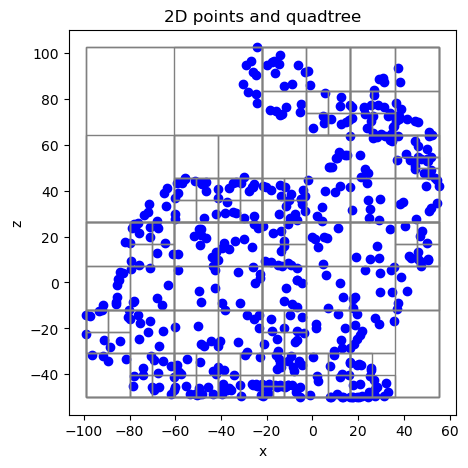

In [37]:
# Build the quadtree
quadtree = QuadTree(points_sample_2d)

# Plot the 2D points with the quadtree
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(points_sample_2d[:, 0], points_sample_2d[:, 1], color="blue")
for node in quadtree.nodes:
    anchor_point, length, width = node.geometry    
    rect = Rectangle(anchor_point, length, width,
                     color="gray", fill=False, lw=1)
    ax.add_patch(rect)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.axis("equal")
ax.set_title("2D points and quadtree")
plt.show()

The same principles can be used to construct an octree. Instead of recursively subdividing the space into four quadrants, each node is subdivided into eight octants.

The implementation below also includes a maximum subdivision depth to prevent the tree from growing indefinitely.

In [ ]:
class OcTree:
    """Partition 3D space by recursively subdividing it into eight octants."""
    
    class OctNode:
        """A node of our Octree or octant."""

        def __init__(self, depth, bound_min, bound_max, indices):

            self.depth = depth # Distance from the root
            self.bound_min = bound_min # Bottom-left corner
            self.bound_max = bound_max # Top-right corner
            self.indices = indices # Point indices
            self.children = [] # Leaf by default

        @property
        def geometry(self):
            """Geometry of the node as a rectangular cuboid."""

            anchor_point = self.bound_min
            length, width, height = self.bound_max - self.bound_min
            
            return anchor_point, length, width, height
        
        @property
        def is_leaf(self):
            """A terminal/leaf node does not have children."""

            return not len(self.children)

        def distance(self, point):
            """Distance between a point and the cuboid."""

            offset = np.max(
                [[0., 0., 0.],
                 self.bound_min - point,
                 point - self.bound_max],
                 axis=0
            )
            # Squared distances for efficiency
            return np.sum(offset**2)

    def __init__(self, points, max_leaf_size=10, max_depth=10):

        self.points = points
        self.max_leaf_size = max_leaf_size
        self.max_depth = max_depth
        # Create root node
        bound_min = points.min(axis=0)
        bound_max = points.max(axis=0) + 1e-8 # slightly enlarge
        indices = np.arange(len(points), dtype=int)
        self.root = OcTree.OctNode(0, bound_min, bound_max, indices)
        # Recursively build the tree
        self._split_node(self.root)
    
    def _split_node(self, node):
        """Recursively split a node into eight subnodes/children."""

        # Do not split if already too small or if reached the maximum depth
        if (len(node.indices) <= self.max_leaf_size 
            or node.depth >= self.max_depth):
            return
        # Compute the bounds of the eight candidate subnodes
        x_center, y_center, z_center = (node.bound_min + node.bound_max)/2
        x_min, y_min, z_min = node.bound_min
        x_max, y_max, z_max = node.bound_max
        new_bounds = [ 
            # South-West-Back
            (np.array([x_min, y_min, z_min]),
             np.array([x_center, y_center, z_center])),
            # North-West-Back
            (np.array([x_min, y_min, z_center]),
             np.array([x_center, y_center, z_max])),
            # North-East-Back
            (np.array([x_min, y_center, z_center]),
             np.array([x_center, y_max, z_max])),
            # South-East-Back
            (np.array([x_min, y_center, z_min]),
             np.array([x_center, y_max, z_center])),
            # South-West-Front
            (np.array([x_center, y_min, z_min]),
             np.array([x_max, y_center, z_center])),
            # North-West-Front
            (np.array([x_center, y_min, z_center]),
             np.array([x_max, y_center, z_max])),
            # North-East-Front
            (np.array([x_center, y_center, z_center]),
             np.array([x_max, y_max, z_max])),
            # South-East-Front
            (np.array([x_center, y_center, z_min]),
             np.array([x_max, y_max, z_center]))
        ]
        # Compute the node points falling into each subnode
        for (bound_min_new, bound_max_new) in new_bounds:
            in_subnode = np.logical_and(
                (self.points[node.indices] >= bound_min_new).all(axis=1), 
                (self.points[node.indices] < bound_max_new).all(axis=1)
            )
            # A subnode is created only if it contains some points
            if np.any(in_subnode):
                subnode = OcTree.OctNode(
                    node.depth + 1, # Increment depth
                    bound_min_new,
                    bound_max_new, 
                    node.indices[in_subnode]
                )
                node.children.append(subnode)
                # Recursively subdivide until leaves are small enough
                self._split_node(subnode)
        # Clear node indices after the node is split (only store for leaves)
        node.indices = []

    @property
    def nodes(self):
        """List of OctNodes composing our OcTree."""

        octree_nodes = [self.root]
        # Breadth-first search
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            for subnode in node.children:
                octree_nodes.append(subnode)
                queue.append(subnode)
        
        return octree_nodes
    
    def knn_search(self, query_point, k):
        """Nearest neighbors search"""
      
        # Store the list of nearest neighbors as (distance, index) using a 
        # max-heap so that the farthest neighbor is always the first element
        # (distance need to be negated to use the min-heap of heapq)
        nearest_neighbors = []
        # Store the list of nodes to explore as (distance, node) using a 
        # min-heap so that the closest node is always the first element
        priority_queue = []
        heapq.heappush(priority_queue, (0., self.root))
        while priority_queue:
            # Select the node with the smallest distance
            dist, node = heapq.heappop(priority_queue)
            # Skip nodes that are too far during backtracking
            if len(nearest_neighbors) == k and dist > -nearest_neighbors[0][0]:
                continue
            # If it's a leaf node, check all points in it
            if node.is_leaf:
                squared_dists = np.sum(
                    (self.points[node.indices] - query_point)**2,
                    axis=1
                )
                for ind, dist in zip(node.indices, squared_dists):
                    # Add the point to the list of nearest neighbors
                    if len(nearest_neighbors) < k:
                        heapq.heappush(nearest_neighbors, (-dist, ind))
                    # if already neighbors, check if worth adding
                    else:
                        # replaces the current farthest neighbor
                        if dist < -nearest_neighbors[0][0]:
                            heapq.heapreplace(nearest_neighbors, (-dist, ind))
            # Else add its children to the priority queue
            else:
                for child in node.children:
                    # If not k neighbors yet, add all children to the queue
                    child_dist = child.distance(query_point)
                    heapq.heappush(priority_queue, (child_dist, child))

        # Extract the indices of the k nearest neighbors
        d, i = zip(*sorted(nearest_neighbors, reverse=True))

        return np.sqrt(-np.asarray(d)), np.array(i)

    def ball_search(self, query_point, r):
        """Search neighbors within a radius"""

        neighbors_within_radius = []
        # Dive into the tree
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            # Only consider nodes that are within a radius r of the query point
            if node.distance(query_point) <= r**2: # distances are squared
                # If it's a leaf node, check all points in it
                if node.is_leaf:            
                    # Compute distances to the query point
                    squared_dists = np.sum(
                        (self.points[node.indices] - query_point)**2,
                        axis=1
                    )
                    # Select points within a radius r
                    inds_within_r = node.indices[
                        np.argwhere(squared_dists < r**2).flatten()
                    ]
                    # Add to list of neighbors
                    neighbors_within_radius.extend(inds_within_r.tolist())
                # Else, add child nodes to the queue
                else:
                    queue.extend(node.children)
    
        return neighbors_within_radius



As observed below, octant size adapts to the local point density. Dense regions are subdivided more deeply, resulting in smaller octants, while sparse regions are represented by larger octants.

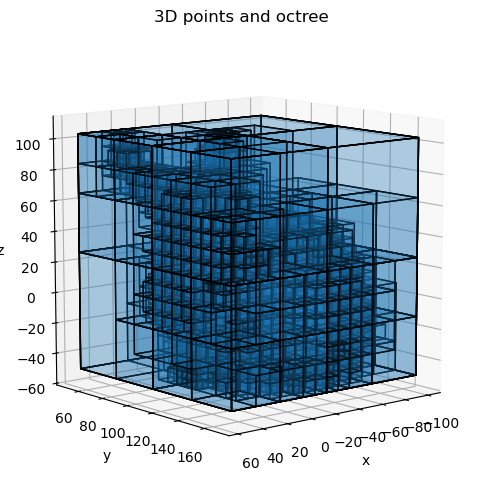

In [39]:
# Build octree with our 3D pointcloud
octree = OcTree(points)

# Plot the octree nodes as cuboids
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          color="blue", alpha=0.1)
polys = []
for octnode in octree.nodes:
    anchor_point, length, width, height = octnode.geometry
    polys.append(cuboid_to_poly3D(anchor_point, (length, width, height)))
polys = np.concatenate(polys)
pc = Poly3DCollection(polys, edgecolor="k", alpha=0.1)
ax.add_collection3d(pc)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 50)
ax.set_box_aspect([1, 1, 1])
plt.title("3D points and octree")
plt.show()

The main advantage of an octree is that it adapts to the local point density. Dense regions are subdivided into many small octants, while sparse regions are represented by fewer and larger octants.

A **$k$-nearest-neighbor search** proceeds as follows:

1. Start from the root node.
2. Visit the octants that are closest to the query point first.
3. When a leaf node is reached, compare the query point with the points it contains.
4. Keep track of the current $k$ nearest neighbors found so far.
5. Skip octants that cannot contain closer neighbors.

This allows large parts of the pointcloud to be ignored during the search.

To decide whether an octant should be explored, the distance between the query point and the octant is computed. This distance is zero when the point lies inside the octant and increases as the point moves away from it.

For an octant with bounds $(b_{min}, b_{max})$, the distance is given by:

\begin{equation*}
d(p, C) = \sqrt{d_x^2 + d_y^2 + d_z^2}
\end{equation*}

where

\begin{equation*}
d_x = \max\{0,\ b_{min,x} - p_x,\ p_x - b_{max,x}\}
\end{equation*}

and similarly for $d_y$ and $d_z$.

In practice, the implementation below uses squared distances to avoid unnecessary square-root computations.

In [40]:
_, knn_octree = octree.knn_search(query_point, k)

print(f"The {k} nearest neighbors are points #", knn_octree)
print("Same neighbors as brute force:",
      np.array_equal(np.sort(knn_octree), np.sort(knn_brute_force)))

The 5 nearest neighbors are points # [ 183  893 3550   53  221]
Same neighbors as brute force: True


A **radius search** proceeds as follows:

1. Start from the root node.
2. Ignore octants whose distance to the query point is greater than the search radius $r$.
3. When a leaf node is reached, compare the query point with the points it contains.
4. Keep only the points whose distance to the query point is smaller than $r$.

As for the k-nn search, large parts of the tree can be skipped during the search. Only octants that may contain points within the search radius need to be explored.

The distance between the query point and an octant is computed as described above.

In [41]:
ball_octree = octree.ball_search(query_point, r)

print(f"Points within radius {r} are points #", ball_octree)
print("Same neighbors as brute force:",
    np.array_equal(np.sort(ball_octree), np.sort(ball_brute_force)))

Points within radius 50 are points # [4021, 449, 1952, 2216, 3663, 1402, 4057, 221, 2014, 2369, 3550, 268, 3106, 287, 436, 1135, 1342, 1900, 2002, 2399, 53, 183, 893]
Same neighbors as brute force: True


## kd-trees

A kd-tree is a **binary tree data structure** designed to organize points in a $k$-dimensional space through recursive space partitioning \cite{bentley1975multidimensional}.

Unlike an octree, which divides the space into eight regions at each subdivision, a kd-tree splits the space into only two regions at a time. Each subdivision is performed along a single dimension, with the splitting dimension changing as the tree grows. The partition is usually chosen so that each child node contains approximately the same number of points. This results in a relatively balanced tree, in which most leaves are located at a similar depth.

In the implementation below, each node of the kd-tree stores:

* The indices of the points it contains (empty in case of inner node);
* Its child nodes (usually named "left" and "right", empty in case of leaf nodes);
* The splitting dimension (empty in case of leaf nodes);
* The splitting value (empty in case of leaf nodes).

As for the octree implementation, only leaf nodes store point indices. Once a node is subdivided, its points are distributed among its children and the indices are removed from the parent node. Unlike the octree, nodes do not explicitly store their geometric extent. The corresponding regions can be reconstructed from the sequence of splits applied from the root node.
The tree is built as follows:

1. Create a root node containing all points of the pointcloud.
2. Select a splitting dimension.
3. Compute the median along this dimension.
4. Split the points into two groups around the median.
5. Repeat the last steps recursively until each leaf contains no more than a given number of points.

Other stopping criteria may also be used, such as limiting the maximum depth of the tree.

In [ ]:
class KdTree:
    
    class KdNode:

        def __init__(self, indices):
 
            self.indices = indices # indices of points it contains
            # Assume terminal by default
            self.left = None # Left child
            self.right = None # Right child
            self.split_dim = None # Splitting dimension
            self.split_val = None # Splitting value
        
        @property
        def is_leaf(self):
            """A terminal/leaf node does not have children."""
            return self.left is None and self.right is None
    
    def __init__(self, points, max_leaf_size=10):

        self.points = points
        self.max_leaf_size = max_leaf_size
        self.n_dims = points.shape[-1] # the dimension or k of the kd-tree
        self.bounding_box = (points.min(axis=0), points.max(axis=0))
        # Create root node
        indices = np.arange(len(points), dtype=int)
        self.root = KdTree.KdNode(indices)
        # Recursively build the tree
        self._split_node(self.root, split_dim=0)
    
    def _split_node(self, node, split_dim):
        """Recursively split a node into two subnodes."""

        # Do not split if node is already too small
        if len(node.indices) <= self.max_leaf_size:
            return
        # Store the split dimension
        node.split_dim = split_dim
        # Compute the split value
        split_val = np.median(self.points[node.indices, split_dim])
        node.split_val = split_val     
        # Compute the node points falling into the left and right subnodes
        in_left_subnode = self.points[node.indices, split_dim] <= split_val
        in_right_subnode = self.points[node.indices, split_dim] > split_val
        # Avoid degenerate split and (infinite recursion)
        if np.all(in_left_subnode) or np.all(in_right_subnode):
            return
        left_subnode = KdTree.KdNode(node.indices[in_left_subnode])
        right_subnode = KdTree.KdNode(node.indices[in_right_subnode])
        node.left = left_subnode
        node.right = right_subnode  
        # Split subnodes further (until children are too small)
        new_split_dim = (split_dim + 1) % self.n_dims
        self._split_node(left_subnode, new_split_dim)
        self._split_node(right_subnode, new_split_dim)
        # Clear node indices after the node is split (only store for leaves)
        node.indices = []

    @property
    def nodes(self):
        """List of KdNodes composing our KdTree."""

        kdtree_nodes = [self.root]
        # Explore the tree using breadth-first search
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            if not node.is_leaf:
                kdtree_nodes.append(node.left)
                queue.append(node.left)
                kdtree_nodes.append(node.right)
                queue.append(node.right)
        
        return kdtree_nodes
    
    @property
    def nodes_geometry(self):
        """Hyper-rectangle geometry of the KdTree nodes."""

        # Store the hyper-rectangle of the root node to start
        hyper_rectangles = []
        # Explore the tree using breadth-first search
        queue = [(self.root, self.bounding_box)]
        while queue:
            node, bounds = queue.pop(0)
            # Store the hyper-rectangle of the current node
            b_min, b_max = bounds
            hyper_rectangles.append((b_min, b_max - b_min))
            # Compute the bound of the two subnodes
            if not node.is_leaf:
                b_mid_min = np.copy(b_min)
                b_mid_min[node.split_dim] = node.split_val
                b_mid_max = np.copy(b_max)
                b_mid_max[node.split_dim] = node.split_val
                left_bounds = (b_min, b_mid_max)
                right_bounds = (b_mid_min, b_max)
                # Add the two subnodes to the queue
                queue.append((node.left, left_bounds))
                queue.append((node.right, right_bounds))

        return hyper_rectangles
    
    def knn_search(self, query_point, k):
        """Nearest neighbors search."""
        
        # Store the list of nearest neighbors as (distance, index) using a 
        # max-heap so that the farthest neighbor is always the first element
        # (distance need to be negated to use the min-heap of heapq)
        nearest_neighbors = []
        # Store nodes to explore in order of increasing distance
        priority_queue = []
        heapq.heappush(priority_queue, (0., self.root))
        while priority_queue:
            # Select the node with the smallest distance
            dist, node = heapq.heappop(priority_queue)
            # Skip nodes that are too far during backtracking
            if len(nearest_neighbors) == k and dist > -nearest_neighbors[0][0]:
                continue
            # If it's a leaf node, check all points in it
            if node.is_leaf:
                squared_dists = np.sum(
                    (self.points[node.indices] - query_point)**2,
                    axis=1
                )
                for ind, dist in zip(node.indices, squared_dists):
                    # Add the point to the list of nearest neighbors
                    if len(nearest_neighbors) < k:
                        heapq.heappush(nearest_neighbors, (-dist, ind))
                    # if already k neighbors, check if is worth adding
                    else:
                        # replaces the current farthest neighbor
                        if dist < -nearest_neighbors[0][0]:
                            heapq.heapreplace(nearest_neighbors, (-dist, ind))
            # Else add its children to the priority queue
            else:
                diff = query_point[node.split_dim] - node.split_val
                # Add child node on the same side as the query point first
                if diff <= 0:
                    close, far = node.left, node.right
                else:
                    close, far = node.right, node.left
                # Add the closest child node to the queue
                heapq.heappush(priority_queue, (0., close))
                # Check if we need to explore the other child node
                heapq.heappush(priority_queue, (diff**2, far))

        # Extract the indices of the k nearest neighbors
        d, i = zip(*sorted(nearest_neighbors, reverse=True))

        return np.sqrt(-np.asarray(d)), np.array(i)

    def ball_search(self, query_point, r):
        """Search neighbors within a radius."""

        # If the query point is too far from the bounding box, return empty
        bound_min, bound_max = self.bounding_box
        deltas = np.max([
            [0., 0., 0.],
            bound_min - query_point,
            query_point - bound_max
        ], axis=0)
        dist_to_bbox = np.sum(deltas**2)
        if dist_to_bbox > r**2: # squared distances
            return np.array([])
        
        neighbors_within_radius = []
        # Explore the tree breadth-first
        queue = [self.root]
        while queue:
            # Select the node with the smallest distance
            node = queue.pop(0)
            # If it's a leaf node, check all points in it
            if node.is_leaf:
                # Compute distances to the query point
                squared_dists = np.sum(
                    (self.points[node.indices] - query_point)**2,
                    axis=1
                )
                # Select points within a radius r
                inds_within_r = node.indices[squared_dists < r**2]
                # Add to list of neighbors
                neighbors_within_radius.extend(inds_within_r.tolist())

            # Else add its children to the queue
            else:
                diff = query_point[node.split_dim] - node.split_val
                if diff <= 0:
                    close, far = node.left, node.right
                else:
                    close, far = node.right, node.left

                if abs(diff) <= r:
                    queue.append(close)
                    queue.append(far)
                else:
                    queue.append(close)       

        return np.array(neighbors_within_radius)


As observed below, the size and shape of the cells are not uniform. Because kd-trees split one dimension at a time, some cells may become long and thin.

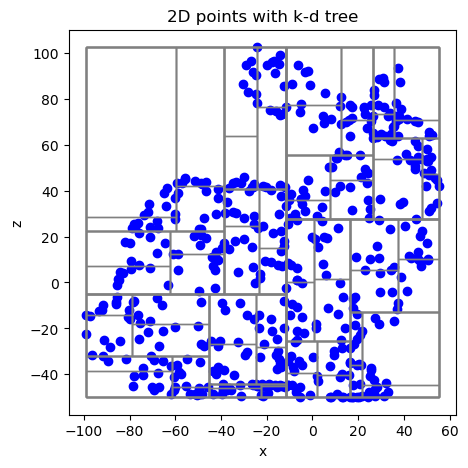

In [ ]:
# Build the kd-tree
kdtree = KdTree(points_sample_2d)

# Plot the points and kd-tree
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(points_sample_2d[:, 0], points_sample_2d[:, 1],
          color="blue")
# Plot the kdtree nodes as rectangles
for hyper_rectangle in kdtree.nodes_geometry:
    anchor_point, dimensions = hyper_rectangle
    length, width = dimensions
    # kd-tree nodes as rectangles
    rect = Rectangle(anchor_point, length, width, 
                     color="gray", fill=False, lw=1)
    ax.add_patch(rect)
ax.set_xlabel('x')
ax.set_ylabel('z')
plt.axis("equal")
plt.title("2D points with kd-tree")
plt.show()

The same applies in 3D. Unlike octrees, which produce regular subdivisions, kd-trees often generate cuboids of very different sizes and shapes.

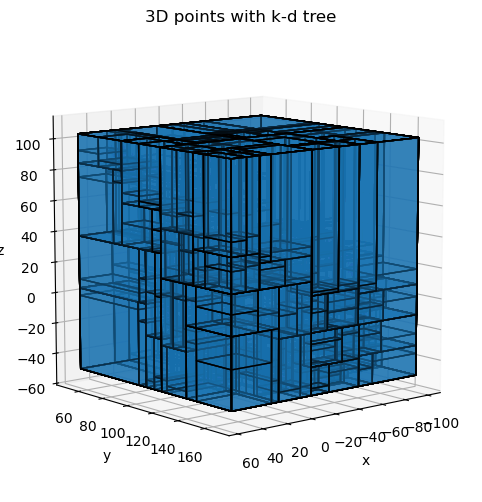

In [ ]:
# Build the kd-tree
kdtree = KdTree(points)

# Plot the points and kdtree
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          color="blue", alpha=0.1)
# Plot the kdtree nodes as cuboids
polys = []
for hyper_rectangle in kdtree.nodes_geometry:
    anchor_point, dimensions = hyper_rectangle
    length, width, height = dimensions
    polys.append(cuboid_to_poly3D(anchor_point, (length, width, height)))
polys = np.concatenate(polys)
pc = Poly3DCollection(polys, edgecolor="k", alpha=0.1)
ax.add_collection3d(pc)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 50)
ax.set_box_aspect([1, 1, 1])
ax.set_title("3D points with kd-tree")
plt.show()

The **$k$-nearest-neighbor search** is similar to the one used with the octree and takes advantage of the hierarchical nature of the kd-tree.

It proceeds as follows:

1. Start from the root node.
2. Explore the side of each split that contains the query point first.
3. When a leaf node is reached, compare the query point with the points it contains.
4. Keep track of the current $k$ nearest neighbors found so far.
5. Explore the opposite side of a split only if it may contain closer neighbors.

This allows large parts of the tree to be ignored during the search.

To decide whether the opposite side of a split must be explored, the distance between the query point $p$ and the splitting plane $P$ is computed. For a splitting dimension $n$ and a splitting value $v$, this distance is given by:

\begin{equation*}
    d(p, P) = p_n - v
\end{equation*}

The sign indicates on which side of the split the query point lies. A negative value corresponds to the left side of the split, while a positive value corresponds to the right side.

The distance to the opposite side of the split is therefore simply $|p_n - v|$. If this distance is larger than the distance to the current farthest neighbor, the opposite side can safely be ignored.

In [ ]:
_, knn_kdtree = kdtree.knn_search(query_point, k)

print(f"The {k} nearest neighbors are points #", knn_kdtree)
print("Same neighbors as brute force:",
      np.array_equal(np.sort(knn_kdtree), np.sort(knn_brute_force)))

The 5 nearest neighbors are points # [ 183  893 3550   53  221]
Same neighbors as brute force: True


A **radius search** proceeds as follows:

1. Start from the root node.
2. Explore the side of each split that contains the query point.
3. Explore the opposite side only if it may contain points within the search radius $r$.
4. When a leaf node is reached, compare the query point with the points it contains.
5. Keep only the points whose distance to the query point is smaller than $r$.

As for the $k$-nn search, large parts of the tree can be ignored during the search.

To determine whether both sides of a split must be explored, the distance between the query point $p$ and the splitting plane $P$ is computed. For a splitting dimension $n$ and splitting value $v$, this distance is given by:

\begin{equation*}
    d(p, P) = |p_n - v|
\end{equation*}

If $d(p, P) \leq r$, the search sphere intersects the splitting plane and both child nodes must be explored. Otherwise, only the child node located on the same side of the split as the query point needs to be considered.

In [ ]:
ball_kdtree = kdtree.ball_search(query_point, r)

print(f"Points within radius {r} are points #", ball_kdtree)
print("Same neighbors as brute force:",
      np.array_equal(np.sort(ball_kdtree), np.sort(ball_brute_force)))

Points within radius 50 are points # [3106 4021   53  183  221  893 2014 2369 3550  436  449 1135 1952 2216
 2399 3663 1402  287 1342  268 1900 2002 4057]
Same neighbors as brute force: True


## Quick comparison

The previous sections introduced three common data structures used for pointcloud processing. But how do they compare in practice?

The comparison below focuses on three common operations: construction from points, insertion/deletion of points and nearest neighbor searches. It uses **time-complexity**, which describes how the running time of an algorithm grows with the size of its input.

Using the "big-O notation", with $n$ the number of points, $O(1)$ denotes constant time (same amount of time regardless of the input size), $O(\log n)$ logarithmic time (time increases slowly as the input size grows), $O(n)$ linear time (time increases proportionally to the input size), and $O(n \log n)$ linearithmic time (time grows faster than linear time but slower than quadratic time).

The values shown below correspond to typical or average-case behavior. Actual performance depends on implementation details, point distributions, and the parameters used to build each structure.

| Structure | Construction | Insertion/Deletion | Nearest Neighbor Search |
|:----------|:-------------|:-------------------|:------------------------|
| Voxel grid| $O(n)$ | $O(1)$ | $O(1)$ (best), $O(n)$ (worst) |
| Octree    | $O(n \log n)$ | $O(\log n)$ | $O(\log n)$ |
| kd-tree   | $O(n \log n)$ | $O(\log n)$ | $O(\log n)$ |


A voxel grid is the simplest structure to build and maintain. Constructing it only requires assigning each point to a voxel, which is done in linear time. Inserting or deleting a point only requires updating the corresponding voxel. The efficiency of nearest-neighbor searches depends strongly on the chosen voxel size. If the resolution is appropriate, only a small number of voxels need to be explored. If the resolution is poorly chosen, it may approach the cost of a brute-force search.

Octrees require recursively subdividing the space into octants. This additional hierarchy increases construction costs but allows large regions of space to be ignored during neighborhood searches. The performance of insertion, deletion, and nearest-neighbor queries is typically logarithmic when the tree remains reasonably balanced.

kd-trees recursively partition points using splitting planes, usually chosen from the data distribution itself. As a result, the tree is often more balanced than an octree and may require visiting fewer regions during nearest-neighbor searches. However, frequent insertions and deletions may require rebuilding or rebalancing the tree, so kd-trees are particularly well suited to static or slowly changing pointclouds.

In practice, there is no universally best structure. Voxel grids are simple, memory-efficient, and easy to update. Octrees adapt naturally to variations in point density. kd-trees often provide the best nearest-neighbor search performance on static datasets. The most appropriate choice depends on the characteristics of the pointcloud and the required operations.

## Going further

The implementations presented in this notebook are kept simple to illustrate the underlying principles of spatial indexing. In practice, many variants and optimizations exist, often targeting specific objectives. This section briefly presents a few common alternatives.

### Voxel grid

Although voxel grids are conceptually simple, several implementation choices are possible in practice:

1. **Dense voxel grids**.
   All voxels are stored explicitly in a multidimensional array. This allows direct indexing but becomes impractical when the occupied space is sparse.

2. **Sparse voxel grids**.
   Only occupied voxels are stored, typically using a hash table. This is the approach used in this notebook and in many pointcloud processing libraries.

3. **Hierarchical voxel grids**.
   Multiple voxel sizes are used simultaneously, allowing the pointcloud to be represented at different resolutions. Octrees can be viewed as a particular form of hierarchical voxel grid.

Instead of storing only point indices, voxels may also store aggregated information such as point counts, average coordinates, colors, or normals. This is commonly used for downsampling and machine-learning applications.

### Octree

Several data structures may be used to implement an octree in practice, depending on the application and constraints:

1. **Tree-based octrees**.
This is the most intuitive representation and the one used in this notebook. Each node explicitly stores links to its children, making the tree structure easy to navigate and modify.

2. **Array-based octrees**.
This approach is well suited to *full octrees*, in which every internal node has exactly eight children. All nodes can then be stored in a flat array instead of using explicit parent-child links. The position of each node in the array implicitly defines its location in the hierarchy.

3. **Linear octrees**.
In this approach, nodes are stored in a hash table and identified by a code describing their position in the tree. Typically, each node is assigned a 3‑bit index (from 0 to 7) corresponding to its octant, which is concatenated with its parent's code to form an octonary identifier. This encoding leads to what is commonly referred to as a *linear octree*, by analogy with the *linear quadtree* \cite{gargantini1982effective}.

4. **Point-code-based octrees**.
In this variant, instead of assigning a code to each node, a code is assigned directly to each point, representing its location across all octree subdivision levels. As in the linear octree representation, the code consists of a concatenation of 3‑bit octant indices. Sorting these codes enables efficient neighborhood queries and traversal operations. This approach is notably used in CloudCompare \cite{girardeau2005change}.

The choice of representation depends on the operations to be performed and the available computational resources. Tree-based octrees are generally easier to modify, while linear representations often reduce memory consumption and improve traversal efficiency.

Also note that the octree cells may also have different shapes, the most common ones being axis-aligned cuboids and axis-aligned cubes. Axis-aligned cuboids better fit the extent of the pointcloud, while cubic cells produce more regular subdivisions and often simplify computations.

### kd-tree

Several variants of kd-trees exist in practice. One of the most important design choices is the **splitting rule**, which determines how the space is partitioned at each node:

1. **The standard split**.
The splitting dimension is chosen as the dimension in which the points have the greatest spread. The splitting value is the median of the points along this dimension. This usually produces well-balanced trees, but may still generate long and thin cells.
 
2. **The midpoint split**.
The splitting dimension is again chosen as the dimension with the greatest spread, but the split is performed at the center of the cell rather than at the median of the points. This approach is similar to a binary version of quadtrees and octrees. It produces more regular cells, but may create empty regions that still need to be explored during queries.

3. **The sliding midpoint split**.
This approach starts with a midpoint split. If all points lie on the same side of the midpoint, the splitting plane is moved toward the points until both child cells contain data. This tends to work well for highly non-uniform point distributions and is the splitting strategy used in the kd-tree implementation of `scipy` \cite{maneewongvatana1999skinny}.

Many other variants and optimizations exist. Depending on the application, memory usage and construction time may be just as important as query performance. For example, approximate median calculations are often used to accelerate the construction of kd-trees for very large pointclouds.

## Wrapping up

You should now have a better understanding of spatial indexing for 3D pointclouds, whose goal is to accelerate common operations such as distance calculations and neighborhood searches. This notebook introduced three widely used data structures: voxel grids, octrees, and kd-trees, each offering different trade-offs for pointcloud processing.

Voxel grids are simple to build and manipulate. They can also serve as a structured representation of a pointcloud, simplifying or even enabling downstream processing tasks (e.g., the use of techniques originally developed for regular image data, such as convolutional neural networks). Their main limitation is that performance depends strongly on the chosen voxel size, which determines the level of detail at which the pointcloud is organized.

Octrees and kd-trees rely on hierarchical subdivisions of space and are generally better suited to neighborhood searches. Octrees are relatively simple to implement and naturally support dynamic pointclouds through point insertion and deletion. kd-trees are typically more efficient for nearest-neighbor searches, especially when point distributions are highly non-uniform, although they may require rebalancing after many updates.

Ultimately, no single data structure is best in all situations. The most appropriate choice depends on the characteristics of the pointcloud, the type of queries being performed, and whether the dataset is static or frequently updated.